# Heart Disease Prediction Using Machine Learning

## Project Overview

This project explores a heart disease dataset and applies multiple
machine learning classification algorithms to predict the heart disease.

The project workflow:

- Data loading
- Data understanding
- Exploratory Data Analysis (EDA)
- Data cleaning
- Feature preprocessing
- Model training
- Model evaluation
- Model comparison
- Model saving

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy.stats import pearsonr

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Model evaluation
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score


from warnings import filterwarnings
filterwarnings('ignore')

__Load Dataset__

In [2]:
df=pd.read_csv(r"heart.csv")

__overview of the dataset__

In [3]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


__No. of rows and column__

In [4]:
df.shape

(918, 12)

__analysing the data set whether it is suitable for training model or not__

In [5]:
df['HeartDisease'].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

_it is a valid dataset so we can use this dataset for training_

__checking for columns dataset consist of__

In [6]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

__data types__

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


_we can see that all the data types are perfect and there are no null values_

__separating categorical and numerical column for inseption__

In [8]:

categorical = df.select_dtypes(include=['object', 'string']).columns.tolist()


numerical = df.select_dtypes(exclude=['object', 'string']).columns.tolist()
print(numerical)
print(categorical)

['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease']
['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


__checking whether categorical columns have valid inputs__

In [9]:
for col in categorical:
    print(f"column: {col}")
    print(f"unique values: {df[col].nunique(dropna=False)}")
    print(df[col].value_counts(dropna=False))
    print('_'*50)

column: Sex
unique values: 2
Sex
M    725
F    193
Name: count, dtype: int64
__________________________________________________
column: ChestPainType
unique values: 4
ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64
__________________________________________________
column: RestingECG
unique values: 3
RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64
__________________________________________________
column: ExerciseAngina
unique values: 2
ExerciseAngina
N    547
Y    371
Name: count, dtype: int64
__________________________________________________
column: ST_Slope
unique values: 3
ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64
__________________________________________________


# Data validation

__Analising Distribution of Numerical Features__  
_to understand the range, spread, and distribution of values and can also to identify unusual values or outliers._

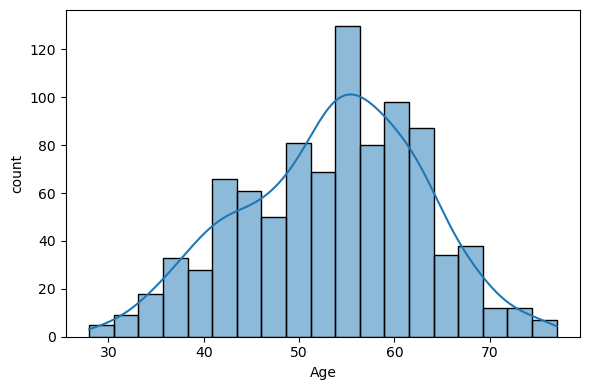

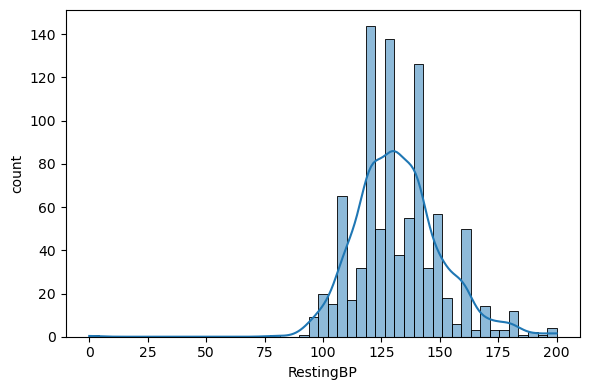

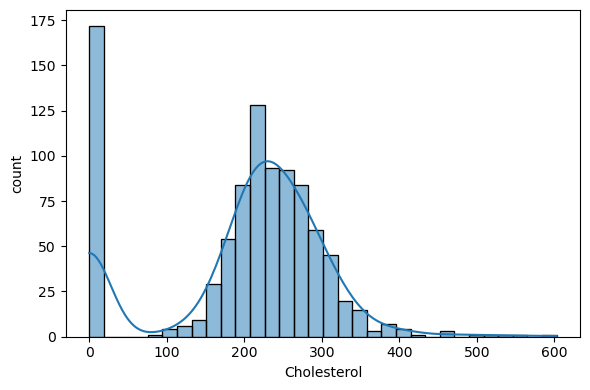

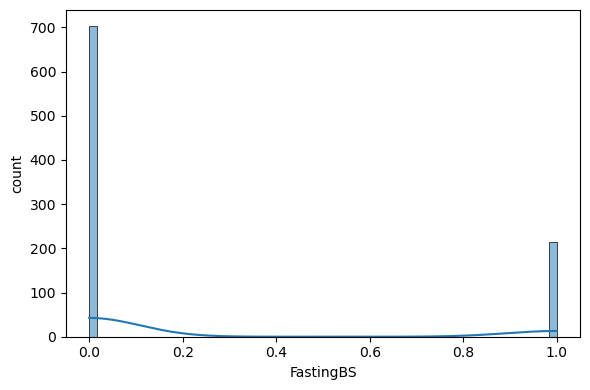

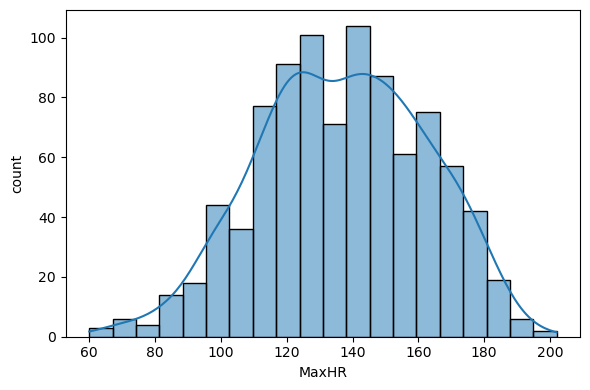

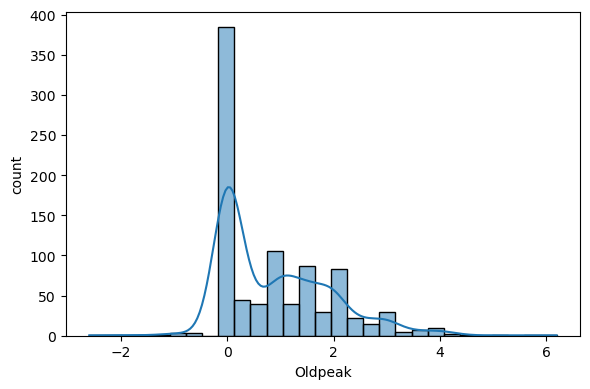

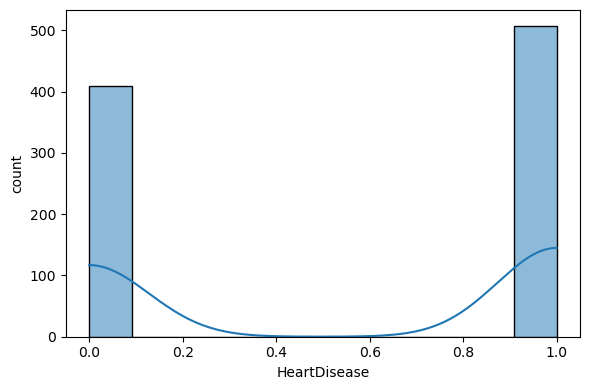

In [10]:
for col in numerical:
    plt.figure(figsize=(6,4))
    
    sns.histplot(
        df[col],
        kde=True
)
    plt.ylabel('count')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

In [11]:
df[numerical].describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


_from the plots we get to know there are invalid values in cholesterol and RestingBP_  
_*)around 170 people has 0 cholesterol but a person can not have 0 cholesterol_  
_*)we have few values with resting blood pressure as 0 is physiologically impossible_

_replacing Cholesterol value which has 0_

In [12]:
cho_mean=df.loc[df['Cholesterol']!=0,'Cholesterol'].mean()
cho_mean

np.float64(244.6353887399464)

In [13]:
cho_median=df.loc[df['Cholesterol']!=0,'Cholesterol'].median()
cho_median

237.0

_we are going to replace 0 with median value because if we use mean there is a max value of 603 but 75%= 267 which may influence the mean value_  

In [14]:
df['Cholesterol']=df['Cholesterol'].replace(0,cho_median).round(2)

_replacing RestingBP value which has 0_

In [15]:
bp_mean=df.loc[df['RestingBP'] !=0,'RestingBP'].mean()

In [16]:
df['RestingBP']=df['RestingBP'].replace(0,bp_mean).round(2)

In [17]:
df[numerical].describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.540893,243.204793,0.233115,136.809368,0.887364,0.553377
std,9.432617,17.989932,53.401297,0.423046,25.460334,1.066570,0.497414
min,28.000000,80.000000,85.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,214.000000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,237.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


__Analising Distribution of categorical Features__  
_to identify how different categories are distributed between patients with and without recorded heart disease._

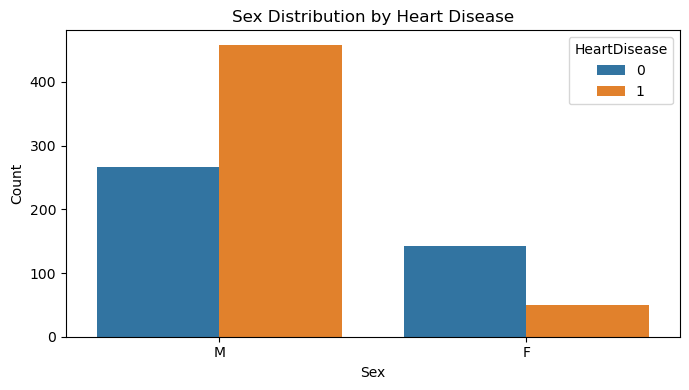

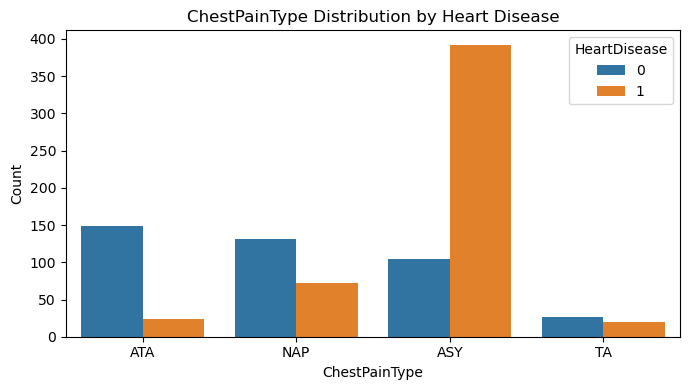

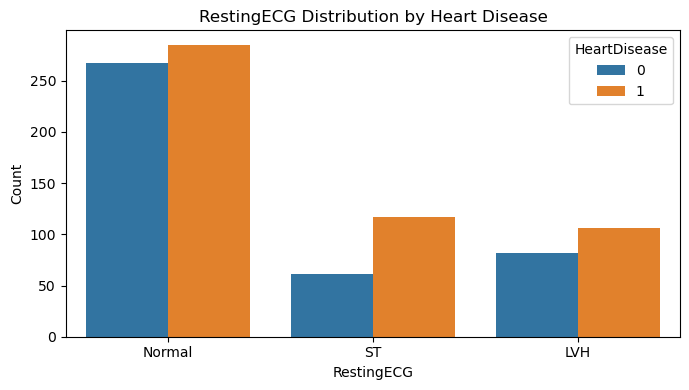

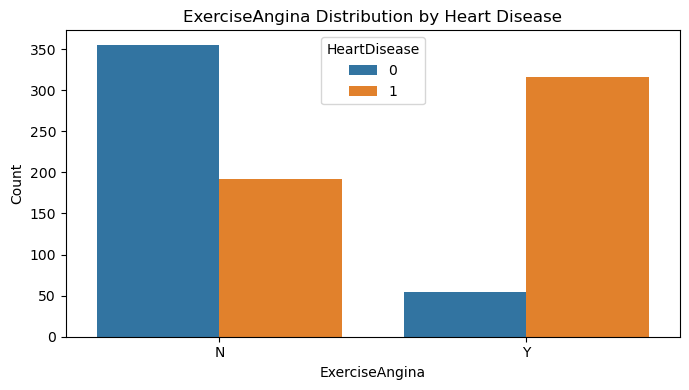

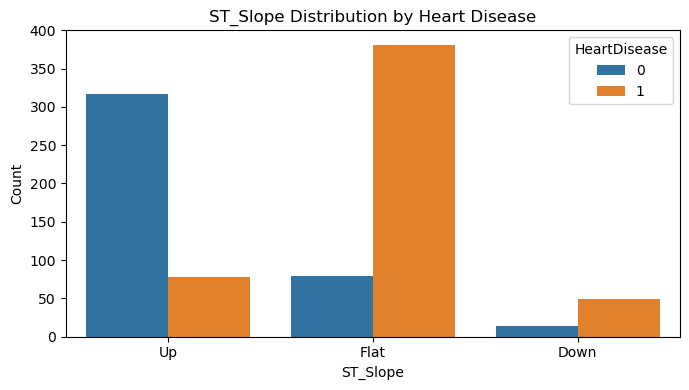

In [18]:
for col in categorical:
    plt.figure(figsize=(7, 4))

    sns.countplot(
        data=df,
        x=col,
        hue='HeartDisease'
    )
    plt.title(f'{col} Distribution by Heart Disease')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

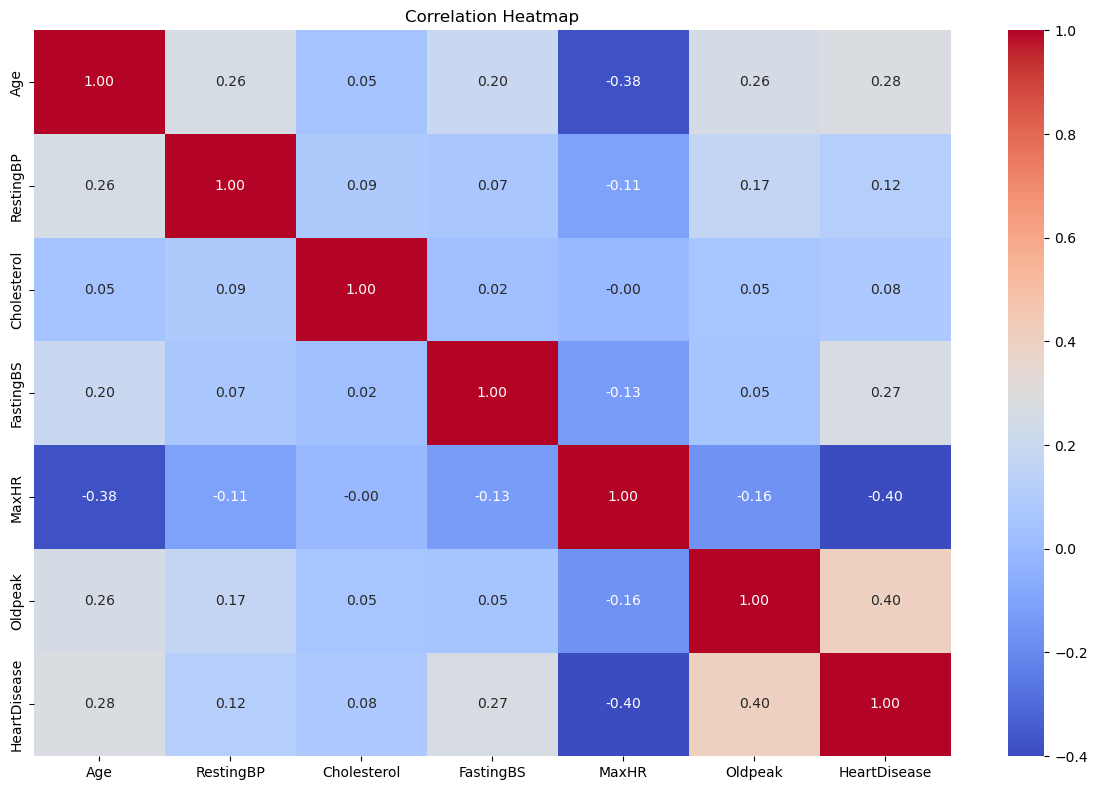

In [19]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [20]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195,0,Normal,122,N,0.0,Up,0


__Categorical Encoding (One-Hot Encoding)__

In [21]:
df=pd.get_dummies(
    data=df,
    columns=categorical,
    drop_first=True,
    dtype='int'
)

__Feature Correlation Analysis (Pearson Correlation)__  
_To understand which features have the strongest linear relationship with our target variable ('HeartDisease') ._

In [31]:
cols=x.columns
corr={
features:pearsonr(df[features],df['HeartDisease'])
for features in cols
}
corr_df=pd.DataFrame(corr.items(),columns=['columns','correlation'])
corr_df.sort_values(by='correlation',ascending=False).round(5)

,columns,correlation
13,ST_Slope_Flat,"(0.5541335908840072, 5.171765655497999e-75)"
12,ExerciseAngina_Y,"(0.4942819918242687, 1.0130182683914526e-57)"
5,Oldpeak,"(0.4039507220628865, 2.3907724240588067e-37)"
6,Sex_M,"(0.30544491596314066, 2.8218978236833408e-21)"
0,Age,"(0.28203850581899725, 3.007953240049735e-18)"
3,FastingBS,"(0.26729118611029823, 1.753598010329966e-16)"
1,RestingBP,"(0.11793802177109096, 0.0003423045514854322)"
11,RestingECG_ST,"(0.10252722218986658, 0.0018684050212259319)"
2,Cholesterol,"(0.07611366790840612, 0.021091906790657138)"
9,ChestPainType_TA,"(-0.05479026202691396, 0.09710611576700866)"


__dividing the dataset for testing and training__

In [23]:
x=df.drop(axis=1,columns=['HeartDisease'])
y=df['HeartDisease']
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

__scaling the values__

In [24]:
scale=StandardScaler()
X_train_scaled=scale.fit_transform(X_train)
x_test_scaled=scale.transform(X_test)

__selecting the best model for training__

In [25]:
models={'logistic_regression':LogisticRegression(),
        'knn':KNeighborsClassifier(),
        'svm':SVC(gamma='auto'),
        'decision_tree':DecisionTreeClassifier(),
        'naive_bayes':GaussianNB()
       }

In [26]:
from sklearn.metrics import accuracy_score
accurate={}
for name,model in models.items():
    model.fit(X_train_scaled,y_train)
    y_pre=model.predict(x_test_scaled)
    accuracy=accuracy_score(y_test,y_pre)
    accurate[name]=accuracy
    print(f"{name} accuracy :{accuracy:.2f}")

logistic_regression accuracy :0.86
knn accuracy :0.85
svm accuracy :0.86
decision_tree accuracy :0.79
naive_bayes accuracy :0.85


__cross validation__

In [43]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    pipe = make_pipeline(StandardScaler(), model)   # scale inside each round
    score = cross_val_score(pipe, X_train, y_train, cv=cv).mean()
    print(f"{name} : cv_score : {score:.2f}")

logistic_regression : cv_score : 0.86
knn : cv_score : 0.84
svm : cv_score : 0.86
decision_tree : cv_score : 0.78
naive_bayes : cv_score : 0.86


__Hyperparameter Tuning for SVM__

In [27]:
classify =GridSearchCV((models['svm']),{
    'kernel':['linear', 'poly', 'rbf', 'sigmoid'],
    'C':[5,10,15,20]
},cv=5)
classify.fit(X_train_scaled,y_train)

,estimator,SVC(gamma='auto')
,param_grid,"{'C': [5, 10, ...], 'kernel': ['linear', 'poly', ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,5


In [28]:
result=pd.DataFrame(classify.cv_results_)
result[['param_C','param_kernel','mean_test_score']].sort_values(by='mean_test_score',ascending=False)

,param_C,param_kernel,mean_test_score
0,5,linear,0.862352
4,10,linear,0.854189
12,20,linear,0.854189
8,15,linear,0.854189
2,5,rbf,0.847386
1,5,poly,0.829699
6,10,rbf,0.818777
7,10,sigmoid,0.818777
3,5,sigmoid,0.817380
5,10,poly,0.811984


__final model evaluation on unseen test data__

In [29]:
best_svm = classify.best_estimator_
y_pre=best_svm.predict(x_test_scaled)
print(f"accuracy score :{accuracy_score(y_test,y_pre):.2f}")
print(f"confusion_matrix :\n{confusion_matrix(y_test,y_pre)}")
print(f"classification_report :\n{classification_report(y_test,y_pre)}")

accuracy score :0.85
confusion_matrix :
[[67 10]
 [17 90]]
classification_report :
              precision    recall  f1-score   support

           0       0.80      0.87      0.83        77
           1       0.90      0.84      0.87       107

    accuracy                           0.85       184
   macro avg       0.85      0.86      0.85       184
weighted avg       0.86      0.85      0.85       184

